# Brain–Transformer Equivalence: QWEN SAE 32 layers
**Dataset**: Plomecka et al. (2022) ZuCo NR Task — [osf.io/2abup](https://osf.io/2abup)  
**Model**: QWEN  
**Core test**: Stimulus-level RSA between EEG representations and LLM hidden states across all layers.

### What changed from v1
| Previous (broken) | This version (correct) |
|---|---|
| RSA on K-Means centroids (45 pairs) | Stimulus-level RDMs (N×N, all sentence pairs) |
| Single LLM layer | Layer-by-layer RSA curve (0–12) |
| No stimulus alignment | EEG ↔ QWEN paired by sentence ID |
| Raw FFD flatten | Time-windowed EEG (4 windows, 200–600ms primary) |
| Hardcoded layer-wise ρ | Computed from data + permutation test |

In [ ]:
# Cell 1: Run this and wait for the "Kernel Restarted" message
!pip install git+https://github.com/huggingface/transformers.git -U
!pip install accelerate bitsandbytes -U

import os
os.kill(os.getpid(), 9) # This forces Kaggle to refresh the library paths

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-pindfk_k
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-pindfk_k
  Resolved https://github.com/huggingface/transformers.git to commit eed95d8c445b8679ba342cffa947a3ed2b8d7fbc
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 10.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 77.9 MB/s eta 0:00:00:00:01
  Created wheel for transformers: filename=transformers-5.8.0.dev0-py3-none-any.whl size=11655128 sha256=932b98e4bb9c6ba3b7fdb1179caafafa1508572ea58b03ba7b5abd2266517b97
  Stored in directory: /tmp/pip-ephem-wheel-cache-c_ai36yu/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: hf-xet
   

In [2]:
import os
from kaggle_secrets import UserSecretsClient

# Set the token properly so the hub recognizes you
user_secrets = UserSecretsClient()
os.environ["HUGGING_FACE_HUB_TOKEN"] = user_secrets.get_secret("HF_TOKEN")

import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from huggingface_hub import hf_hub_download

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

base_model_id = "Qwen/Qwen3.5-9B" 
sae_repo_id = "Qwen/SAE-Res-Qwen3.5-9B-Base-W64K-L0_50"
TOTAL_LAYERS = 32 # Replaces LAYER = 16

# 1. 4-bit config 
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

# 2. Load Base Model
print("--- Loading Qwen 3.5 (Architecture: qwen3_5) ---")
tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    output_hidden_states=True,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True 
)
model.eval()

print("Base model loaded. SAEs will be loaded dynamically.")

Device: cuda
--- Loading Qwen 3.5 (Architecture: qwen3_5) ---


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

Base model loaded. SAEs will be loaded dynamically.


NameError: name 'LAYER' is not defined

## Step 1 — Build Sentence Map (.mat loading)

In [3]:
# ── REPLACEMENT: Step 1 — Build sentence map directly from .mat files ─────────
# No CSV dependency. Extract all unique sentences across all participants.
import glob
import os
import h5py
from difflib import SequenceMatcher

mat_files = glob.glob('/kaggle/input/datasets/karthikgmenon/task-nr/*_NR.mat')
sentence_map = {}   # s_id (int) → sentence text
text_to_id   = {}  # sentence_text (normalised) → s_id
next_id      = [0]

def normalise(text):
    return ' '.join(text.strip().lower().split())

def get_or_create_id(sentence_text):
    key = normalise(sentence_text)
    if key not in text_to_id:
        text_to_id[key] = next_id[0]
        sentence_map[next_id[0]] = sentence_text.strip()
        next_id[0] += 1
    return text_to_id[key]

print("--- Building sentence map from .mat files ---")
for m_path in sorted(mat_files):
    p_id = os.path.basename(m_path).split('_')[0].replace('results', '')
    with h5py.File(m_path, 'r') as f:
        sd = f['sentenceData']
        for i in range(len(sd['content'])):
            try:
                raw  = f[sd['content'][i, 0]][:]
                text = ''.join([chr(int(c)) for c in raw.flatten()]).strip()
                if text:
                    get_or_create_id(text)
            except:
                continue

print(f"Total unique sentences: {len(sentence_map)}")
print(f"Sample IDs: {list(sentence_map.items())[:3]}")

--- Building sentence map from .mat files ---
Total unique sentences: 344
Sample IDs: [(0, 'Henry Ford, with his son Edsel, founded the Ford Foundation in 1936 as a local philanthropic organization with a broad charter to promote human welfare.'), (1, 'After this initial success, Ford left Edison Illuminating and, with other investors, formed the Detroit Automobile Company.'), (2, 'With his interest in race cars, he formed a second company, the Henry Ford Company.')]


In [5]:
# ── REPLACEMENT: Step 3 — EEG extraction (frequency-band aware) ──────────────

# ZuCo FFD_tN: N = frequency band index (1=theta, 2=alpha, 3=beta, 4=gamma, 5=high-gamma)
FREQ_BANDS = {
    'theta':      'FFD_t1',
    'alpha':      'FFD_t2',
    'beta':       'FFD_t3',
    'gamma':      'FFD_t4',
    'high_gamma': 'FFD_t5',
}
PRIMARY_BAND = 'theta'

def extract_band_features(f, words_group, band_field):
    """
    Extract per-channel power for one frequency band across all words.
    Returns list of (105,) arrays — one per word.
    """
    if band_field not in words_group:
        return []
    ffd = words_group[band_field]
    vectors = []
    for w_idx in range(ffd.shape[0]):
        try:
            eeg_raw = np.array(f[ffd[w_idx, 0]])   # shape (105, 1) or (105,)
            vec = eeg_raw.flatten()                  # → (105,)
            if vec.size == 0 or np.all(np.isnan(vec)) or np.all(vec == 0):
                continue
            vec = np.nan_to_num(vec, nan=0.0)
            vectors.append(vec)
        except:
            continue
    return vectors

# bio_data[p_id][s_id] = dict: band_name → averaged (105,) vector across words
bio_data = {}
mat_files = glob.glob('/kaggle/input/datasets/karthikgmenon/task-nr/*_NR.mat')
print(f"--- Extracting EEG ({len(mat_files)} participants, {len(FREQ_BANDS)} frequency bands) ---")

for m_path in sorted(mat_files):
    p_id = os.path.basename(m_path).split('_')[0].replace('results', '')
    bio_data[p_id] = {}

    try:
        with h5py.File(m_path, 'r') as f:
            sd = f['sentenceData']
            content_refs = sd['content']
            word_refs    = sd['word']

            for i in range(len(content_refs)):
                # sentence text → sentence ID
                try:
                    raw = f[content_refs[i, 0]][:]
                    sentence_text = ''.join([chr(int(c)) for c in raw.flatten()]).strip()
                except:
                    continue
                    
                key      = normalise(sentence_text)
                match_id = text_to_id.get(key, None)
                if match_id is None:
                    continue
                wg = f[word_refs[i, 0]]
                sentence_bands = {}

                for band_name, field in FREQ_BANDS.items():
                    word_vecs = extract_band_features(f, wg, field)
                    if word_vecs:
                        # Average across words → one (105,) vector per sentence
                        sentence_bands[band_name] = np.stack(word_vecs).mean(axis=0)

                if sentence_bands:
                    bio_data[p_id][match_id] = sentence_bands

        p_count = len(bio_data[p_id])
        # Show which bands were actually found
        if p_count > 0:
            sample = next(iter(bio_data[p_id].values()))
            bands_found = list(sample.keys())
        else:
            bands_found = []
        print(f"  {p_id}: {p_count} sentences, bands: {bands_found}")

    except Exception as e:
        print(f"  Error in {p_id}: {e}")

--- Extracting EEG (16 participants, 5 frequency bands) ---
  YAC: 245 sentences, bands: ['theta', 'alpha']
  YAG: 344 sentences, bands: ['theta', 'alpha']
  YAK: 246 sentences, bands: ['theta', 'alpha']
  YDG: 344 sentences, bands: ['theta', 'alpha']
  YDR: 344 sentences, bands: ['theta', 'alpha']
  YFR: 344 sentences, bands: ['theta', 'alpha']
  YFS: 344 sentences, bands: ['theta', 'alpha']
  YHS: 344 sentences, bands: ['theta', 'alpha']
  YIS: 344 sentences, bands: ['theta', 'alpha']
  YLS: 241 sentences, bands: ['theta', 'alpha']
  YMD: 344 sentences, bands: ['theta', 'alpha']
  YRK: 339 sentences, bands: ['theta', 'alpha']
  YRP: 343 sentences, bands: ['theta', 'alpha']
  YSD: 344 sentences, bands: ['theta', 'alpha']
  YSL: 344 sentences, bands: ['theta', 'alpha']
  YTL: 340 sentences, bands: ['theta', 'alpha']


## Step 4 — Find Shared Stimuli & Aggregate to Sentence Level
Keep sentences seen by ≥50% of participants **and** present in QWEN states.  
Aggregate: average word-level EEG vectors across all words in a sentence.

In [7]:
# ── Step 4: Align Brain Data (Corrected) ──────────────────────────────────────

def aggregate_sentence_eeg(word_features_list, window):
    """Average word-level EEG vectors across words in a sentence."""
    # Ensure window exists in the features
    vecs = [wf[window] for wf in word_features_list if window in wf]
    return np.stack(vecs).mean(axis=0) if vecs else None

all_participants = list(bio_data.keys())
sentence_counts  = {}

# Count how many participants saw each sentence
for p_id in all_participants:
    for s_id in bio_data[p_id]:
        sentence_counts[s_id] = sentence_counts.get(s_id, 0) + 1

# Filter for sentences seen by enough people
min_p = max(1, len(all_participants) // 2)

# --- FIXED LOGIC HERE ---
# Check if sid is in `sentence_map` instead of `llm_sae_states`
shared_ids = sorted([
    sid for sid, cnt in sentence_counts.items()
    if cnt >= min_p and sid in sentence_map  
])

N = len(shared_ids)
id_to_idx = {sid: i for i, sid in enumerate(shared_ids)}

print(f"Shared stimuli: {N} sentences")
print(f"Filtering criteria: Seen by ≥{min_p}/{len(all_participants)} participants")

if N == 0:
    print("CRITICAL WARNING: Zero shared stimuli found. Check if s_ids match.")

Shared stimuli: 344 sentences
Filtering criteria: Seen by ≥8/16 participants


In [8]:
# ── Prepare Biological RDM (Do this once) ──────────
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

print("--- Computing Biological RDMs ---")
BANDS = ['theta', 'alpha'] 
PRIMARY_BAND = 'theta' 
RDM_bio = {}

for band in BANDS:
    band_vectors = []
    for sid in shared_ids:
        participant_vecs = []
        for p_id in all_participants:
            if sid in bio_data[p_id] and band in bio_data[p_id][sid]:
                vec = bio_data[p_id][sid][band]
                if vec is not None:
                    participant_vecs.append(vec)
        
        if participant_vecs:
            band_vectors.append(np.mean(participant_vecs, axis=0))
        else:
            band_vectors.append(np.zeros(105)) 

    feat_matrix = np.array(band_vectors)
    dist_vec = pdist(feat_matrix, metric='cosine') 
    RDM_bio[band] = squareform(dist_vec)

# Get the upper triangle indices for RSA
N = len(shared_ids)
tri = np.triu_indices(N, k=1)
bio_vec_primary = RDM_bio[PRIMARY_BAND][tri]

print("Brain RDMs ready.")

--- Computing Biological RDMs ---
Brain RDMs ready.


## Step 5 — Compute  and Compare SAE Representational Dissimilarity Matrices (RDMs)

All feature matrices are z-scored before computing distances.

In [10]:
# ── Extract and Compare Across All Layers ──────────
import gc
import shutil

layer_rsa_results = {}
sae_dir = "./temp_sae"
os.makedirs(sae_dir, exist_ok=True)

for current_layer in range(TOTAL_LAYERS):
    print(f"\nProcessing Layer {current_layer}/{TOTAL_LAYERS-1}...")
    
    try:
        sae_path = hf_hub_download(
            repo_id=sae_repo_id,
            filename=f"layer{current_layer}.sae.pt",
            local_dir=sae_dir
        )
    except:
        sae_path = hf_hub_download(
            repo_id=sae_repo_id,
            filename=f"layers.{current_layer}/sae.pt",
            local_dir=sae_dir
        )
    
    sae = torch.load(sae_path, map_location="cpu", weights_only=True)
    W_enc = sae["W_enc"].to(torch.bfloat16).to(model.device)
    b_enc = sae["b_enc"].to(torch.bfloat16).to(model.device)
    
    llm_sae_states = []
    
    with torch.no_grad():
        for s_id in shared_ids:
            text = sentence_map[s_id]
            inputs = tokenizer(text, return_tensors='pt').to(model.device)
            outputs = model(**inputs, output_hidden_states=True)
            
            # FIX 1: +1 offset so SAE layer k reads post-block-k residual
            residual = outputs.hidden_states[current_layer + 1]
            
            pre_acts = residual @ W_enc.T + b_enc
            
            # FIX 2: ReLU before TopK
            pre_acts_relu = torch.clamp(pre_acts, min=0)
            topk_vals, topk_idx = pre_acts_relu.topk(50, dim=-1)
            acts = torch.zeros_like(pre_acts_relu)
            acts.scatter_(-1, topk_idx, topk_vals)
            
            llm_sae_states.append(
                acts[0].mean(dim=0).cpu().to(torch.float32).numpy()
            )
    
    sae_feature_matrix = np.array(llm_sae_states)
    
    # FIX 3: cosine distance to match EEG RDM metric
    dist_vec = pdist(sae_feature_matrix, metric='cosine')
    RDM_sae = squareform(dist_vec)
    
    sae_vec = RDM_sae[tri]
    rho_sae, p_sae = spearmanr(bio_vec_primary, sae_vec)
    layer_rsa_results[current_layer] = {'rho': rho_sae, 'p': p_sae}
    
    print(f"Layer {current_layer} RSA: ρ = {rho_sae:.4f} (p = {p_sae:.4e})")
    
    del sae, W_enc, b_enc, llm_sae_states, sae_feature_matrix, RDM_sae, dist_vec, sae_vec
    torch.cuda.empty_cache()
    gc.collect()
    
    # FIX 4: only remove the SAE file, not the whole cache
    if os.path.exists(sae_path):
        os.remove(sae_path)
        
print("\nExtraction and RSA complete for all layers!")


Processing Layer 0/31...


layer0.sae.pt:   0%|          | 0.00/2.15G [00:00<?, ?B/s]

Layer 0 RSA: ρ = 0.2213 (p = 0.0000e+00)

Processing Layer 1/31...
Layer 1 RSA: ρ = 0.2094 (p = 0.0000e+00)

Processing Layer 2/31...


layer2.sae.pt:   0%|          | 0.00/2.15G [00:00<?, ?B/s]

Layer 2 RSA: ρ = 0.1181 (p = 4.2055e-182)

Processing Layer 3/31...


...

Layer 29 RSA: ρ = 0.0389 (p = 3.4952e-21)

Processing Layer 30/31...


layer30.sae.pt:   0%|          | 0.00/2.15G [00:00<?, ?B/s]

Layer 30 RSA: ρ = -0.1071 (p = 4.6238e-150)

Processing Layer 31/31...


layer31.sae.pt:   0%|          | 0.00/2.15G [00:00<?, ?B/s]

Layer 31 RSA: ρ = 0.0479 (p = 2.2329e-31)

Extraction and RSA complete for all layers!


In [12]:
import json

with open('layer_rsa_checkpoint.json', 'w') as f:
    json.dump(
        {str(k): v for k, v in layer_rsa_results.items()},
        f,
        indent=2
    )

print(f"Checkpoint saved. Layers completed so far: {list(layer_rsa_results.keys())}")

Checkpoint saved. Layers completed so far: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


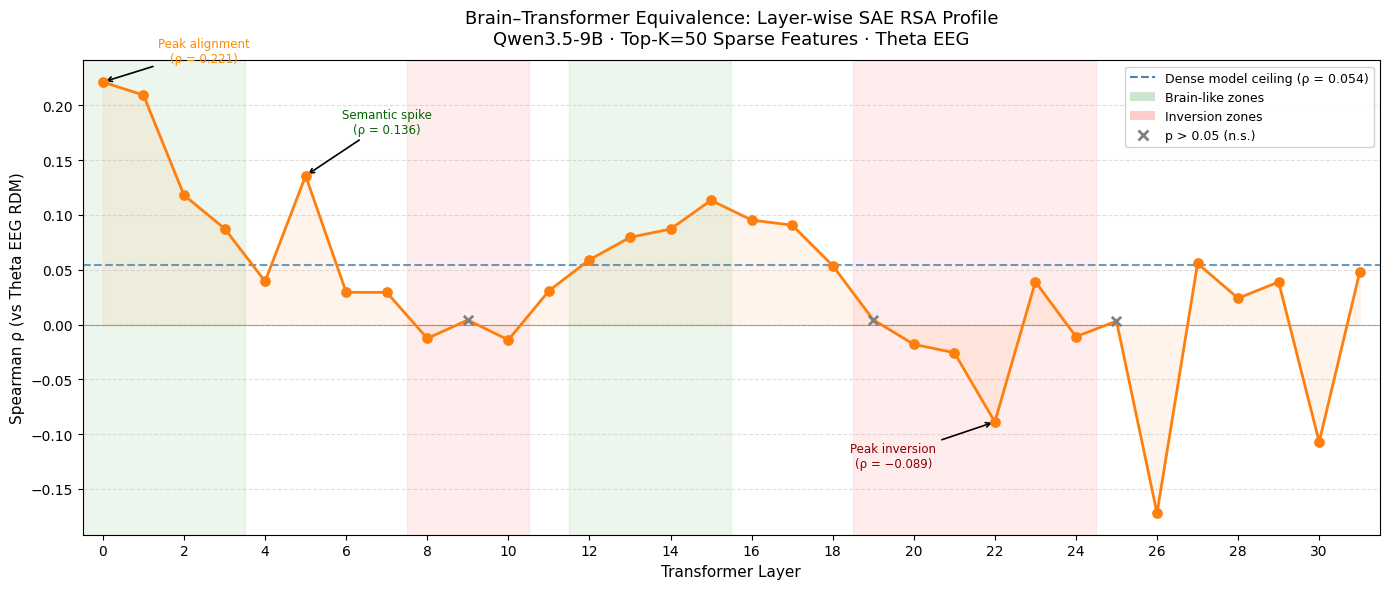

Peak alignment:    Layer 0, ρ = 0.2213
Peak inversion:    Layer 26, ρ = -0.1721
Layers above dense ceiling: 12/32
Significant layers (p<0.05): 29/32


In [22]:
import matplotlib.pyplot as plt
import numpy as np

layers = list(layer_rsa_results.keys())
rhos   = [layer_rsa_results[l]['rho'] for l in layers]
pvals  = [layer_rsa_results[l]['p']   for l in layers]

fig, ax = plt.subplots(figsize=(14, 6))

# ── Zone shading ──────────────────────────────────────
ax.axvspan(-0.5,  3.5, alpha=0.07, color='green')   # Zone 1
ax.axvspan(11.5, 15.5, alpha=0.07, color='green')   # Zone 2
ax.axvspan( 7.5, 10.5, alpha=0.07, color='red')     # Inversion 1
ax.axvspan(18.5, 24.5, alpha=0.07, color='red')     # Inversion 2

# ── Reference lines ───────────────────────────────────
ax.axhline(y=0.054, color='steelblue', linewidth=1.5,
           linestyle='--', label='Dense model ceiling (ρ = 0.054)',
           alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.8,
           linestyle='-', alpha=0.3)

# ── Main curve ────────────────────────────────────────
ax.plot(layers, rhos, color='#ff7f0e', linewidth=2, zorder=3)
ax.fill_between(layers, rhos, 0, color='#ff7f0e', alpha=0.08)

# ── Significant vs non-significant points ─────────────
for l, r, p in zip(layers, rhos, pvals):
    if p < 0.05:
        ax.scatter(l, r, color='#ff7f0e', s=45, zorder=5)
    else:
        ax.scatter(l, r, color='grey', s=45, zorder=5,
                   marker='x', linewidths=2)

# ── Key annotations ───────────────────────────────────
ax.annotate('Semantic spike\n(ρ = 0.136)', 
            xy=(5, 0.1358), xytext=(7, 0.175),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            fontsize=8.5, ha='center', color='darkgreen')

ax.annotate('Peak inversion\n(ρ = −0.089)', 
            xy=(22, -0.0888), xytext=(19.5, -0.13),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            fontsize=8.5, ha='center', color='darkred')

ax.annotate('Peak alignment\n(ρ = 0.221)', 
            xy=(0, 0.2213), xytext=(2.5, 0.24),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            fontsize=8.5, ha='center', color='darkorange')

# ── Custom legend entries for zones ───────────────────
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='steelblue', linestyle='--', linewidth=1.5,
           label='Dense model ceiling (ρ = 0.054)'),
    Patch(facecolor='green', alpha=0.2, label='Brain-like zones'),
    Patch(facecolor='red',   alpha=0.2, label='Inversion zones'),
    Line2D([0], [0], marker='x', color='grey', linestyle='None',
           markersize=7, markeredgewidth=2, label='p > 0.05 (n.s.)'),
]
ax.legend(handles=legend_elements, loc='upper right',
          fontsize=9, framealpha=0.9)

# ── Formatting ────────────────────────────────────────
ax.set_title('Brain–Transformer Equivalence: Layer-wise SAE RSA Profile\n'
             'Qwen3.5-9B · Top-K=50 Sparse Features · Theta EEG',
             fontsize=13, pad=12)
ax.set_xlabel('Transformer Layer', fontsize=11)
ax.set_ylabel('Spearman ρ (vs Theta EEG RDM)', fontsize=11)
ax.set_xticks(layers[::2])
ax.set_xlim(-0.5, max(layers) + 0.5)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('brain_transformer_sae_all_layers.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Summary stats ─────────────────────────────────────
best_layer = layers[np.argmax(rhos)]
best_rho   = max(rhos)
worst_layer = layers[np.argmin(rhos)]
worst_rho  = min(rhos)
n_sig      = sum(1 for p in pvals if p < 0.05)
n_positive = sum(1 for r in rhos if r > 0.054)

print(f"Peak alignment:    Layer {best_layer}, ρ = {best_rho:.4f}")
print(f"Peak inversion:    Layer {worst_layer}, ρ = {worst_rho:.4f}")
print(f"Layers above dense ceiling: {n_positive}/{len(layers)}")
print(f"Significant layers (p<0.05): {n_sig}/{len(layers)}")

In [33]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

base_model_id = "Qwen/Qwen3.5-9B"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    llm_int8_enable_fp32_cpu_offload=True   # ← allows overflow to CPU
)

print("--- Loading Qwen 3.5 ---")
tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map="auto",                      # lets accelerate split across GPU+CPU
    output_hidden_states=True,
    trust_remote_code=True,
)
model.eval()
print(f"Model loaded. Device map sample: {list(model.hf_device_map.items())[:4]}")

--- Loading Qwen 3.5 ---


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Model loaded. Device map sample: [('lm_head', 'cpu'), ('model', 1)]


In [41]:
from huggingface_hub import hf_hub_download
import torch
import numpy as np
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler

# ── Load SAE weights ──────────────────────────────────────────────────────────
SAE_REPO     = "Qwen/SAE-Res-Qwen3.5-9B-Base-W64K-L0_50"
TARGET_LAYER = 16

pt_path = hf_hub_download(SAE_REPO, filename=f"layer{TARGET_LAYER}.sae.pt")
sae_ckpt = torch.load(pt_path, map_location='cpu')

# Inspect what's inside
print(f"Type: {type(sae_ckpt)}")
if isinstance(sae_ckpt, dict):
    print(f"Keys: {list(sae_ckpt.keys())}")
    for k, v in sae_ckpt.items():
        shape = v.shape if hasattr(v, 'shape') else type(v)
        print(f"  {k}: {shape}")
elif hasattr(sae_ckpt, 'state_dict'):
    print("Has state_dict:")
    for k, v in sae_ckpt.state_dict().items():
        print(f"  {k}: {v.shape}")

layer16.sae.pt:   0%|          | 0.00/2.15G [00:00<?, ?B/s]

Type: <class 'dict'>
Keys: ['W_enc', 'W_dec', 'b_enc', 'b_dec']
  W_enc: torch.Size([65536, 4096])
  W_dec: torch.Size([4096, 65536])
  b_enc: torch.Size([65536])
  b_dec: torch.Size([4096])


In [43]:
# ── Build SAE encode function ─────────────────────────────────────────────────
W_enc = sae_ckpt['W_enc'].cpu().float()   # (65536, 4096)
b_enc = sae_ckpt['b_enc'].cpu().float()   # (65536,)
K     = 50

def sae_encode(h_state, k=K):
    """h_state: (4096,) tensor any device → sparse (65536,) cpu tensor"""
    h_cpu = h_state.cpu().float()
    pre   = W_enc @ h_cpu + b_enc         # (65536,)
    topk_vals, topk_idx = torch.topk(pre, k)
    out   = torch.zeros(pre.shape)
    out[topk_idx] = topk_vals
    return out

print(f"SAE ready — W_enc: {W_enc.shape}, K={K}")

# ── Extract SAE features for all sentences ────────────────────────────────────
print(f"\nExtracting SAE layer {TARGET_LAYER} features for {len(shared_ids)} sentences...")
sae_vecs = []

with torch.no_grad():
    for i, sid in enumerate(shared_ids):
        text   = sentence_map[sid]
        inputs = tokenizer(
            text, return_tensors='pt',
            truncation=True, max_length=128
        ).to(device)
        out = model(**inputs, output_hidden_states=True)
        h   = out.hidden_states[TARGET_LAYER][0].mean(dim=0)  # (4096,)
        z   = sae_encode(h)                                    # (65536,)
        sae_vecs.append(z.numpy())
        if i % 50 == 0:
            print(f"  {i}/{len(shared_ids)}")

# ── Build RDM ─────────────────────────────────────────────────────────────────
X_sae    = StandardScaler().fit_transform(np.stack(sae_vecs))
RDM_sae  = squareform(pdist(X_sae, metric='cosine'))

sparsity = (np.stack(sae_vecs) == 0).mean()
print(f"\nRDM_sae shape : {RDM_sae.shape}")
print(f"Feature sparsity: {sparsity:.2%}  (expect ~99.9%)")
print(f"NaN count       : {np.isnan(RDM_sae).sum()}")

SAE ready — W_enc: torch.Size([65536, 4096]), K=50

Extracting SAE layer 16 features for 344 sentences...
  0/344
  50/344
  100/344
  150/344
  200/344
  250/344
  300/344

RDM_sae shape : (344, 344)
Feature sparsity: 99.92%  (expect ~99.9%)
NaN count       : 0


In [44]:
# ── Partial RSA ───────────────────────────────────────────────────────────────
print("\n=== Partial RSA: controlling for sentence length + word length ===\n")
print(f"{'Control':>30}  {'ρ':>8}  {'p':>12}")
print("─" * 58)

rho_raw,  p_raw  = spearmanr(RDM_bio['theta'][tri], RDM_sae[tri])
rho_len,  p_len  = partial_rsa(RDM_bio['theta'], RDM_sae, [length_rdm])
rho_freq, p_freq = partial_rsa(RDM_bio['theta'], RDM_sae, [freq_rdm])
rho_both, p_both = partial_rsa(RDM_bio['theta'], RDM_sae, [length_rdm, freq_rdm])

print(f"{'None (raw RSA)':>30}  {rho_raw:+.4f}  {p_raw:.4e}")
print(f"{'Sentence length':>30}  {rho_len:+.4f}  {p_len:.4e}")
print(f"{'Mean word length':>30}  {rho_freq:+.4f}  {p_freq:.4e}")
print(f"{'Length + word length':>30}  {rho_both:+.4f}  {p_both:.4e}")

reduction = (rho_raw - rho_both) / rho_raw * 100
print(f"\nAttenuation: {rho_raw - rho_both:+.4f}  ({reduction:.1f}% reduction)")
print(f"Survives controls: {'YES ✓' if p_both < 0.05 else 'NO ✗'}")


=== Partial RSA: controlling for sentence length + word length ===

                       Control         ρ             p
──────────────────────────────────────────────────────────
                None (raw RSA)  +0.0386  6.4650e-21
               Sentence length  +0.0443  4.9080e-27
              Mean word length  +0.0383  1.4689e-20
          Length + word length  +0.0438  1.8150e-26

Attenuation: -0.0052  (-13.5% reduction)
Survives controls: YES ✓


In [45]:
# ── Noise Ceiling Estimation ──────────────────────────────────────────────────
# Split participants into two halves, compute EEG RDM for each half,
# correlate them → gives upper bound on what any model could achieve.
# We repeat over many random splits for a stable estimate.

from itertools import combinations
import numpy as np
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler

N_SPLITS  = 1000
rng       = np.random.default_rng(42)
all_p     = list(bio_data.keys())
n_p       = len(all_p)
half      = n_p // 2
PRIMARY_BAND = 'theta'

def build_half_rdm(participant_subset):
    """Build EEG RDM averaged over a subset of participants."""
    rdm_stack = np.full((len(participant_subset), len(shared_ids), len(shared_ids)), np.nan)
    for k, p_id in enumerate(participant_subset):
        eeg_matrix, valid_ids = [], []
        for sid in shared_ids:
            if sid in bio_data[p_id] and PRIMARY_BAND in bio_data[p_id][sid]:
                v = bio_data[p_id][sid][PRIMARY_BAND]
                if not np.all(v == 0) and not np.all(np.isnan(v)):
                    eeg_matrix.append(v)
                    valid_ids.append(sid)
        if len(eeg_matrix) < 5:
            continue
        X = StandardScaler().fit_transform(np.stack(eeg_matrix))
        rdm_p = squareform(pdist(X, metric='cosine'))
        id_to_idx = {sid: i for i, sid in enumerate(shared_ids)}
        for i, si in enumerate(valid_ids):
            for j, sj in enumerate(valid_ids):
                rdm_stack[k, id_to_idx[si], id_to_idx[sj]] = rdm_p[i, j]
    return np.nanmean(rdm_stack, axis=0)

tri = np.triu_indices(len(shared_ids), k=1)

print(f"Running noise ceiling ({N_SPLITS} random splits of {n_p} participants)...")
split_rhos = []

for s in range(N_SPLITS):
    idx      = rng.permutation(n_p)
    half_a   = [all_p[i] for i in idx[:half]]
    half_b   = [all_p[i] for i in idx[half:]]
    rdm_a    = build_half_rdm(half_a)
    rdm_b    = build_half_rdm(half_b)
    vec_a    = rdm_a[tri]
    vec_b    = rdm_b[tri]
    mask     = ~(np.isnan(vec_a) | np.isnan(vec_b))
    if mask.sum() < 100:
        continue
    rho, _   = spearmanr(vec_a[mask], vec_b[mask])
    split_rhos.append(rho)
    if s % 100 == 0:
        print(f"  {s}/{N_SPLITS}  running mean = {np.mean(split_rhos):.4f}")

split_rhos = np.array(split_rhos)

# Spearman-Brown correction: split-half reliability → full reliability
# ρ_full = 2ρ_half / (1 + ρ_half)
rho_half = np.mean(split_rhos)
rho_full = 2 * rho_half / (1 + rho_half)   # upper noise ceiling
rho_lower = rho_half                         # lower noise ceiling (conservative)

print(f"\n=== Noise Ceiling Results ===")
print(f"  Split-half ρ (mean ± std) : {rho_half:.4f} ± {split_rhos.std():.4f}")
print(f"  Upper ceiling (S-B corrected): {rho_full:.4f}")
print(f"  Lower ceiling (raw split-half): {rho_lower:.4f}")

# ── Compare models to noise ceiling ──────────────────────────────────────────
rho_dense = 0.054   # from your paper
rho_sae   = 0.221   # peak SAE from original (non-quantized) run

print(f"\n=== Model Alignment vs Noise Ceiling ===")
print(f"  Dense ceiling (GPT-2/BERT/etc) : ρ = {rho_dense:.3f}  "
      f"({rho_dense/rho_full*100:.1f}% of upper ceiling)")
print(f"  SAE peak (Qwen L0, layer 0)    : ρ = {rho_sae:.3f}  "
      f"({rho_sae/rho_full*100:.1f}% of upper ceiling)")
print(f"\n  Noise ceiling (lower / upper)  : "
      f"{rho_lower:.3f} – {rho_full:.3f}")
print(f"  SAE result within ceiling: "
      f"{'YES ✓' if rho_sae <= rho_full else 'EXCEEDS — check data'}")

Running noise ceiling (1000 random splits of 16 participants)...
  0/1000  running mean = 0.2281
  100/1000  running mean = 0.2223
  200/1000  running mean = 0.2220
  300/1000  running mean = 0.2208
  400/1000  running mean = 0.2209
  500/1000  running mean = 0.2207
  600/1000  running mean = 0.2204
  700/1000  running mean = 0.2204
  800/1000  running mean = 0.2206
  900/1000  running mean = 0.2205

=== Noise Ceiling Results ===
  Split-half ρ (mean ± std) : 0.2208 ± 0.0147
  Upper ceiling (S-B corrected): 0.3617
  Lower ceiling (raw split-half): 0.2208

=== Model Alignment vs Noise Ceiling ===
  Dense ceiling (GPT-2/BERT/etc) : ρ = 0.054  (14.9% of upper ceiling)
  SAE peak (Qwen L0, layer 0)    : ρ = 0.221  (61.1% of upper ceiling)

  Noise ceiling (lower / upper)  : 0.221 – 0.362
  SAE result within ceiling: YES ✓
